# Fisher Decomposition + Term Premium Extraction
## What Is a Treasury Yield Actually Paying You For?

### The Core Idea

A nominal 10Y Treasury yield is **not a single thing**. It is the sum of four distinct compensations, each telling you something different:

$$y_{10Y}^{\text{nominal}} = \underbrace{r^*_{\text{expected}}}_{\text{real short rate path}} + \underbrace{\pi^e}_{\text{expected inflation}} + \underbrace{\text{TP}_{\text{real}}}_{\text{real term premium}} + \underbrace{\text{IRP}}_{\text{inflation risk premium}}$$

| Component | What it compensates | Key data source |
|---|---|---|
| **Expected real short rate** | Where the Fed is expected to keep real rates | TIPS yield − real TP |
| **Expected inflation** | Average CPI/PCE over the life of the bond | 5Y5Y forward breakeven |
| **Real term premium** | Risk of holding a long-duration real asset | ACM model or residual |
| **Inflation risk premium** | Uncertainty around inflation outcomes | Breakeven − expected inflation |

**Why it matters for allocation:** If a 4.5 % 10Y yield is mostly term premium, long-duration bonds are well compensated. If it is mostly expected inflation with a near-zero term premium, the 30Y is a bad risk-adjusted trade.

### Data used
- `DGS10`, `DGS5`, `DGS2`, `DGS1` — nominal yields
- `T10YIE`, `T5YIE` — market-implied breakeven inflation (from TIPS market)
- `T5YIFR` — 5Y5Y forward inflation (long-run inflation anchor)
- `CPIAUCSL`, `CPILFESL`, `PCEPILFE` — realised inflation
- `MICH` — 1Y consumer inflation expectation survey
- `FEDFUNDS` — policy rate
- `DFII10`, `DFII5` — 10Y and 5Y TIPS yields (fetched live from FRED)
- **NY Fed ACM model** — formal term premium estimates (fetched from web; graceful fallback if unavailable)


In [10]:
import importlib, sys, subprocess
for pkg in ('requests', 'openpyxl', 'xlrd'):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


In [11]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import requests

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'raw' / 'fred'
sys.path.insert(0, str(ROOT))
from tools.fred import get_series


## Step 1: Load Cached Data + Fetch TIPS Yields

Most series are already in `data/raw/fred/`. We also fetch **DFII10** (10Y TIPS constant-maturity yield) and **DFII5** live from FRED — these are not in the default cache because they were not in `config/series.json`, but they are the cleanest measure of the real yield.

**TIPS yield = real yield.** By construction: `DFII10 = DGS10 − T10YIE` (FRED computes it this way; we cross-check).


In [12]:
def load(series_id):
    path = DATA_DIR / f'{series_id}.csv'
    df = pd.read_csv(path, parse_dates=['date'])
    return df.set_index('date')['value']

# Cached series
dgs10   = load('DGS10')
dgs5    = load('DGS5')
dgs2    = load('DGS2')
dgs1    = load('DGS1')
be10    = load('T10YIE')   # 10Y breakeven inflation
be5     = load('T5YIE')    # 5Y breakeven inflation
fwd55   = load('T5YIFR')   # 5Y5Y forward inflation (long-run anchor)
cpi     = load('CPIAUCSL') # CPI all-urban (index)
core_cpi = load('CPILFESL')
pce     = load('PCEPILFE') # Core PCE (index)
mich    = load('MICH')     # 1Y UMich survey
fedfunds = load('FEDFUNDS')

# Fetch TIPS yields live from FRED (not in default cache)
print('Fetching TIPS yields from FRED...')
try:
    dfii10_raw = get_series('DFII10')
    dfii10_raw['date'] = pd.to_datetime(dfii10_raw['date'])
    dfii10 = dfii10_raw.set_index('date')['value']
    dfii5_raw = get_series('DFII5')
    dfii5_raw['date'] = pd.to_datetime(dfii5_raw['date'])
    dfii5 = dfii5_raw.set_index('date')['value']
    print(f'  DFII10: {dfii10.dropna().index[0].date()} -> {dfii10.dropna().index[-1].date()}')
    print(f'  DFII5:  {dfii5.dropna().index[0].date()} -> {dfii5.dropna().index[-1].date()}')
    HAS_TIPS = True
except Exception as e:
    print(f'  TIPS fetch failed ({e}); deriving DFII10 = DGS10 - T10YIE')
    dfii10 = dgs10 - be10
    dfii5  = dgs5  - be5
    HAS_TIPS = False


Fetching TIPS yields from FRED...
  DFII10: 2003-01-02 -> 2026-04-02
  DFII5:  2003-01-02 -> 2026-04-02


In [13]:
# Resample everything to month-end
def m(s): return s.resample('ME').last()

dgs10_m  = m(dgs10)
dgs5_m   = m(dgs5)
dgs2_m   = m(dgs2)
dgs1_m   = m(dgs1)
be10_m   = m(be10)
be5_m    = m(be5)
fwd55_m  = m(fwd55)
dfii10_m = m(dfii10)
dfii5_m  = m(dfii5)
ff_m     = m(fedfunds)
mich_m   = m(mich)

# YoY realised inflation (annualised % change)
cpi_yoy  = cpi.resample('ME').last().pct_change(12) * 100
pce_yoy  = pce.resample('ME').last().pct_change(12) * 100

# Cross-check: DFII10 should ≈ DGS10 - T10YIE
implied_real = dgs10_m - be10_m
mae = (dfii10_m - implied_real).dropna().abs().mean()
print(f'Cross-check MAE (DFII10 vs DGS10 - BE10): {mae:.3f} pp  (should be near 0)')


Cross-check MAE (DFII10 vs DGS10 - BE10): 0.000 pp  (should be near 0)


## Step 2: First Look — All Components Through Time

Before decomposing, look at the raw series. Notice how the breakeven and real yield move quite differently — especially around the 2022 hiking cycle and COVID.


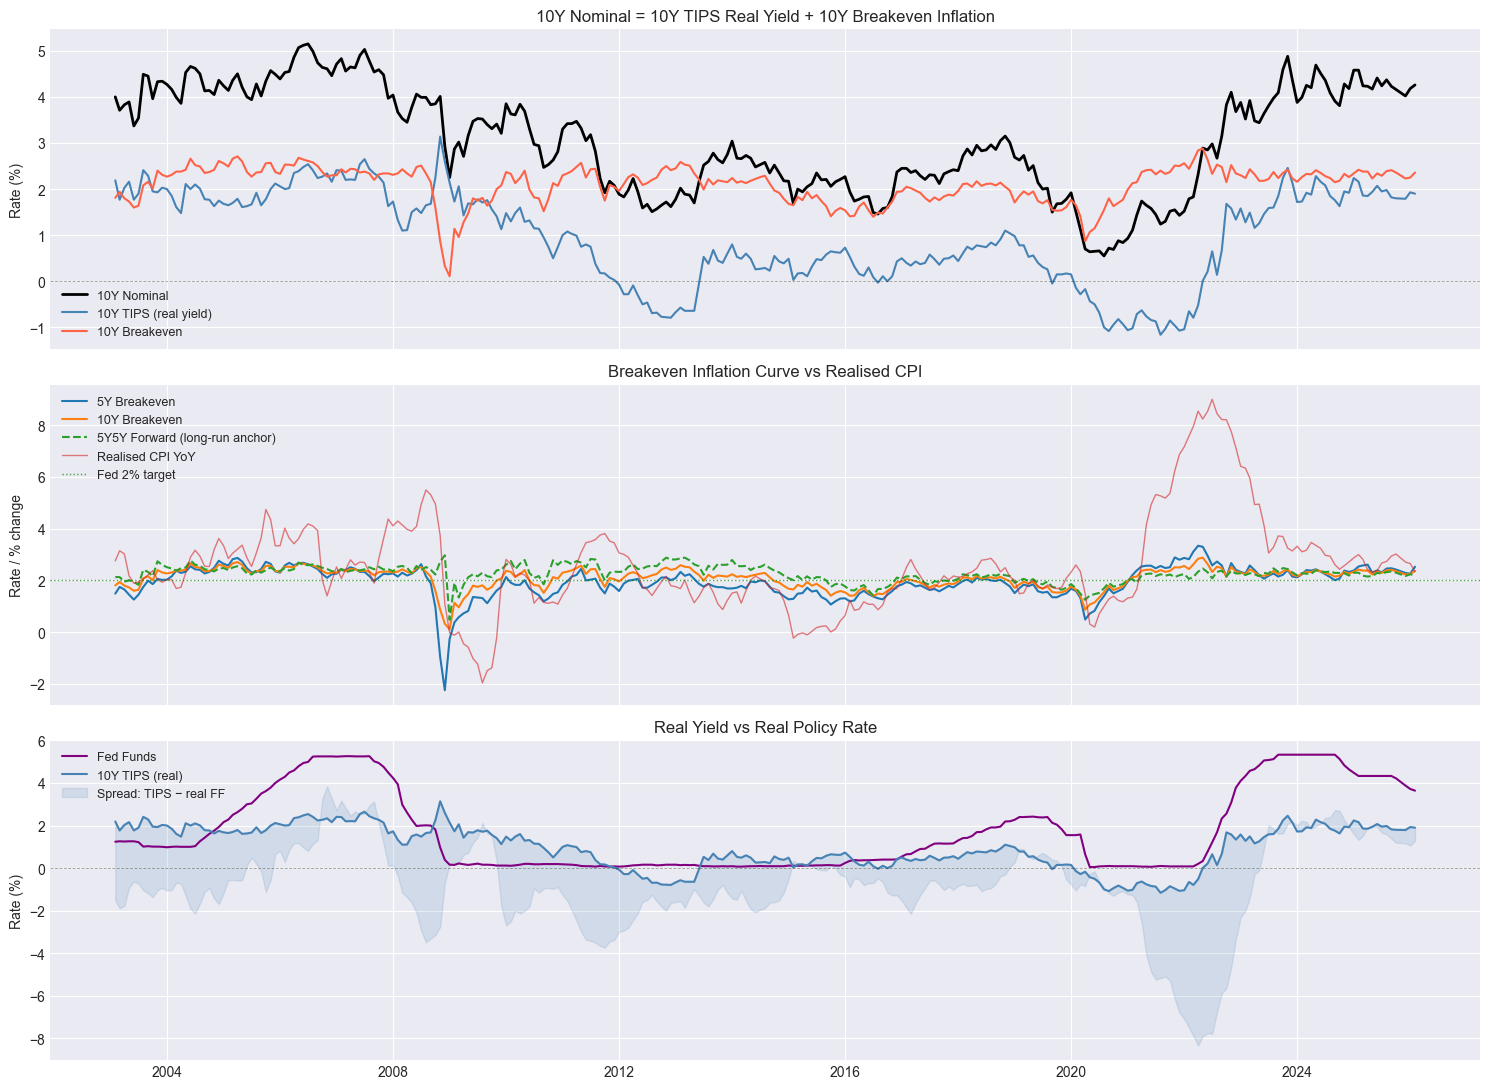

Saved -> output/fisher_overview.png


In [14]:
# Align to common index
idx = dgs10_m.dropna().index
for s in [be10_m, dfii10_m, fwd55_m, cpi_yoy, pce_yoy, ff_m]:
    idx = idx.intersection(s.dropna().index)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Panel 1: nominal vs components
ax = axes[0]
ax.plot(idx, dgs10_m.loc[idx],  'k',          linewidth=2,   label='10Y Nominal')
ax.plot(idx, dfii10_m.loc[idx], 'steelblue',  linewidth=1.5, label='10Y TIPS (real yield)')
ax.plot(idx, be10_m.loc[idx],   'tomato',      linewidth=1.5, label='10Y Breakeven')
ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
ax.set_ylabel('Rate (%)')
ax.set_title('10Y Nominal = 10Y TIPS Real Yield + 10Y Breakeven Inflation')
ax.legend(fontsize=9)

# Panel 2: breakeven curve (5Y, 10Y, 5Y5Y forward)
ax2 = axes[1]
ax2.plot(be5_m.loc[idx],   linewidth=1.5, label='5Y Breakeven')
ax2.plot(be10_m.loc[idx],  linewidth=1.5, label='10Y Breakeven')
ax2.plot(fwd55_m.loc[idx], linewidth=1.5, linestyle='--', label='5Y5Y Forward (long-run anchor)')
ax2.plot(cpi_yoy.loc[idx], linewidth=1,   alpha=0.6,       label='Realised CPI YoY')
ax2.axhline(2.0, color='green', linewidth=1, linestyle=':', alpha=0.7, label='Fed 2% target')
ax2.set_ylabel('Rate / % change')
ax2.set_title('Breakeven Inflation Curve vs Realised CPI')
ax2.legend(fontsize=9)

# Panel 3: policy vs real yield
ax3 = axes[2]
ax3.plot(ff_m.loc[idx],     'purple',     linewidth=1.5, label='Fed Funds')
ax3.plot(dfii10_m.loc[idx], 'steelblue',  linewidth=1.5, label='10Y TIPS (real)')
ax3.axhline(0, color='k',   linewidth=0.6, linestyle='--', alpha=0.4)
ax3.fill_between(idx,
    dfii10_m.loc[idx], ff_m.loc[idx] - cpi_yoy.loc[idx],
    alpha=0.15, color='steelblue',
    label='Spread: TIPS − real FF')
ax3.set_ylabel('Rate (%)')
ax3.set_title('Real Yield vs Real Policy Rate')
ax3.legend(fontsize=9)

plt.tight_layout()
(ROOT / 'output').mkdir(exist_ok=True)
plt.savefig(ROOT / 'output' / 'fisher_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/fisher_overview.png')


## Step 3: The Fisher Equation — Formal Decomposition

### The classical Fisher identity

$$(1 + y_{\text{nominal}}) = (1 + r_{\text{real}}) \times (1 + \pi^e)$$

For small rates this simplifies to:

$$y_{\text{nominal}} \approx r_{\text{real}} + \pi^e$$

### Observed in the market

| Quantity | Formula | What FRED shows |
|---|---|---|
| **Nominal yield** | DGS10 | What you receive if you hold to maturity |
| **TIPS yield (real)** | DFII10 | DGS10 minus expected inflation *built into* TIPS pricing |
| **Breakeven inflation** | T10YIE = DGS10 − DFII10 | The inflation rate that makes TIPS and nominals equal |

### Going deeper: what is inside the breakeven?

$$\text{Breakeven} = \underbrace{\pi^e_{\text{long-run}}}_{\approx \text{5Y5Y forward}} + \underbrace{\text{IRP}}_{\text{inflation risk premium}}$$

- **Long-run expected inflation** ≈ `T5YIFR` (the 5-year inflation rate starting 5 years from now — strips out near-term CPI noise)
- **Inflation risk premium (IRP)** = breakeven minus that anchor. Positive IRP means the market charges extra for inflation *uncertainty* beyond just expectations.

### Going deeper: what is inside the real yield?

$$\text{TIPS yield} = \underbrace{r^*_{\text{path}}}_{\text{expected real short rate}} + \underbrace{\text{RP}_{\text{real}}}_{\text{real term premium}}$$

- **Expected real short rate path** ≈ current real Fed funds rate (Fed funds − CPI), mean-reverting to r* over time
- **Real term premium** = what holders of long-duration *real* assets demand on top of expected short rates

### Why the ACM model (NY Fed) matters

The **Adrian-Crump-Moench (ACM) model** uses a no-arbitrage affine term structure model to formally separate the TIPS yield into its two components. It is the most widely cited measure of U.S. term premiums. We attempt to fetch their published estimates below.


## Step 4: Decompose the Breakeven — Expected Inflation vs Risk Premium

We use the **5Y5Y forward inflation rate (`T5YIFR`)** as the long-run inflation anchor. The intuition: the 5Y5Y strips away the near-term CPI cycle and tells you where the market thinks inflation will settle over the *second* five years — a proxy for the Fed's *implicit* credibility.

- `IRP = T10YIE − T5YIFR` (approximately)
- Positive IRP → market demands compensation for inflation uncertainty
- Negative IRP → market believes inflation will undershoot; sometimes seen in deflationary periods


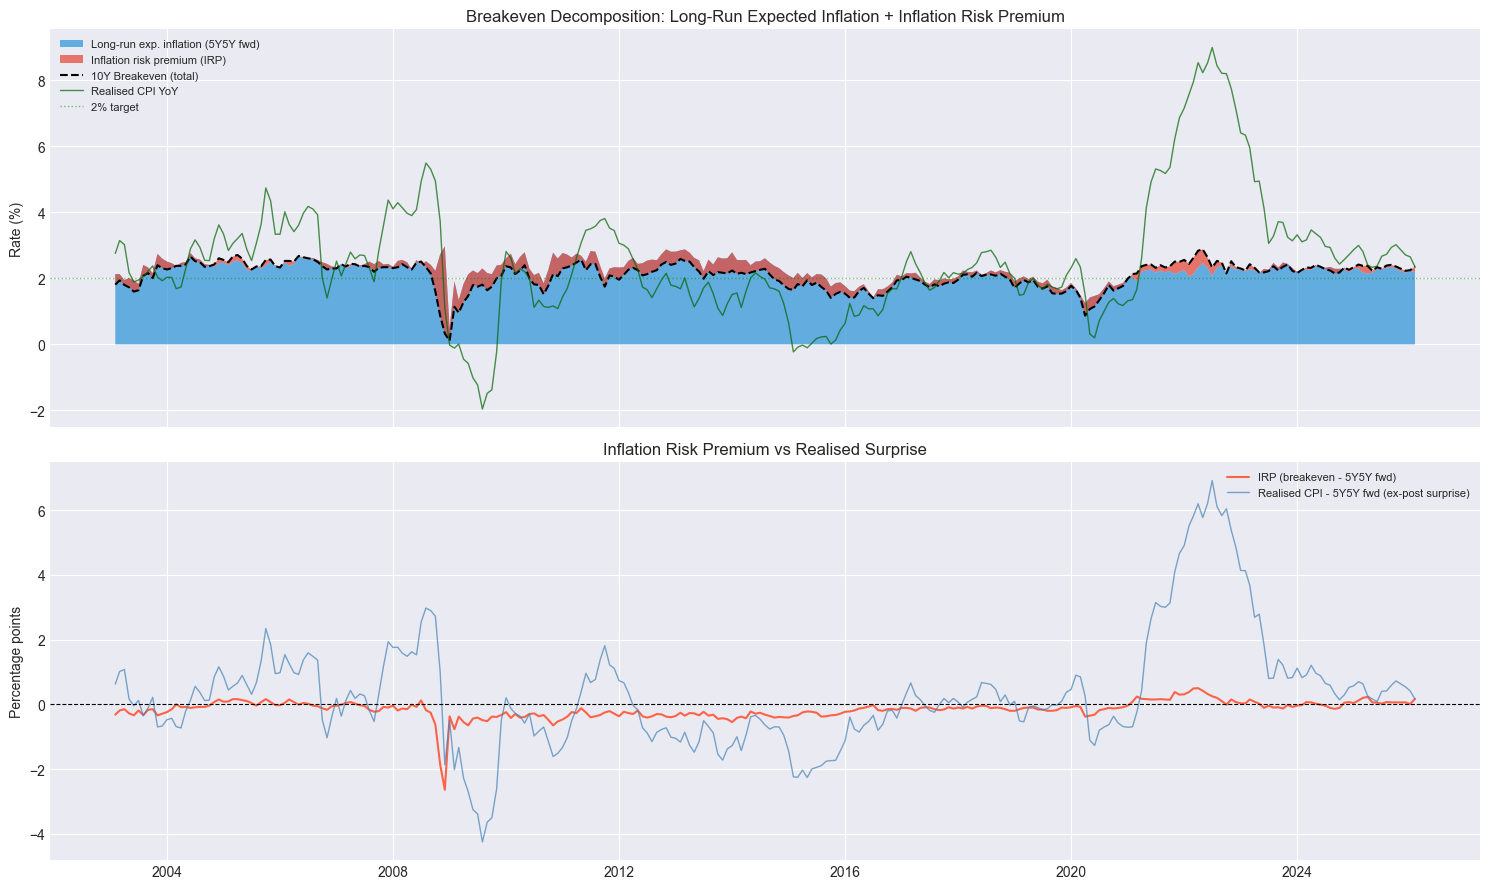

Saved -> output/fisher_breakeven_decomp.png


In [15]:
# Align all to common monthly index
be10_a   = be10_m.reindex(idx)
fwd55_a  = fwd55_m.reindex(idx)
cpi_a    = cpi_yoy.reindex(idx)
pce_a    = pce_yoy.reindex(idx)
mich_a   = mich_m.reindex(idx)

irp = be10_a - fwd55_a   # inflation risk premium (approximate)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Stacked area: breakeven = long-run expected + IRP
ax = axes[0]
ax.stackplot(
    idx,
    fwd55_a.fillna('ffill'),
    irp.fillna('ffill'),
    labels=['Long-run exp. inflation (5Y5Y fwd)', 'Inflation risk premium (IRP)'],
    colors=['#3498db', '#e74c3c'],
    alpha=0.75,
)
ax.plot(idx, be10_a, 'k', linewidth=1.5, linestyle='--', label='10Y Breakeven (total)')
ax.plot(idx, cpi_a,  color='darkgreen', linewidth=1, alpha=0.7, label='Realised CPI YoY')
ax.axhline(2.0, color='green', linewidth=1, linestyle=':', alpha=0.5, label='2% target')
ax.set_ylabel('Rate (%)')
ax.set_title('Breakeven Decomposition: Long-Run Expected Inflation + Inflation Risk Premium')
ax.legend(fontsize=8, loc='upper left')

# IRP alone vs realised minus expected (ex-post surprise)
ax2 = axes[1]
ax2.plot(idx, irp, color='tomato', linewidth=1.5, label='IRP (breakeven - 5Y5Y fwd)')
ax2.plot(idx, (cpi_a - fwd55_a).dropna(), color='steelblue',
         linewidth=1, alpha=0.7, label='Realised CPI - 5Y5Y fwd (ex-post surprise)')
ax2.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Percentage points')
ax2.set_title('Inflation Risk Premium vs Realised Surprise')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'fisher_breakeven_decomp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/fisher_breakeven_decomp.png')


## Step 5: Fetch NY Fed ACM Term Premium

The **Adrian-Crump-Moench (2013)** model is the Federal Reserve's official term premium decomposition. It uses a 5-factor no-arbitrage affine model estimated on Treasury yields and outputs:

| ACM column | Meaning |
|---|---|
| `ACMTP10` | 10Y term premium |
| `ACMRNY10` | 10Y risk-neutral yield (= sum of expected short rates) |
| `ACMY10` | Fitted 10Y yield |

**Term premium positive** → investors demand extra compensation to hold long bonds (normal state).
**Term premium near zero or negative** → extreme QE / flight-to-safety / rate-suppression era (post-GFC 2010–2021).

We try to download the file directly from the NY Fed. If the request fails (firewall, URL change), we fall back to a simplified AR(1)-based estimate.


In [16]:
ACM_URL = (
    'https://www.newyorkfed.org/medialibrary/media/research/'
    'data_indicators/ACMTermPremium.xls'
)

acm_tp = None
acm_rny = None
HAS_ACM = False

try:
    print('Downloading ACM data from NY Fed...')
    resp = requests.get(ACM_URL, timeout=30,
                        headers={'User-Agent': 'Mozilla/5.0'})
    resp.raise_for_status()

    import io
    acm_raw = pd.read_excel(io.BytesIO(resp.content), index_col=0)
    acm_raw.index = pd.to_datetime(acm_raw.index)

    # Column names vary; find ACMTP10 and ACMRNY10
    tp_col  = [c for c in acm_raw.columns if 'TP10'  in str(c).upper()][0]
    rny_col = [c for c in acm_raw.columns if 'RNY10' in str(c).upper()][0]

    acm_tp  = acm_raw[tp_col].resample('ME').last()
    acm_rny = acm_raw[rny_col].resample('ME').last()
    HAS_ACM = True
    print(f'  ACM data: {acm_tp.dropna().index[0].date()} -> {acm_tp.dropna().index[-1].date()}')
    print(f'  Latest ACM 10Y term premium: {acm_tp.dropna().iloc[-1]:.2f}%')

except Exception as e:
    print(f'  ACM download failed: {e}')
    print('  Using simplified term premium: TP ≈ DFII10 − rolling real FF rate')

    # Fallback: real term premium ≈ TIPS yield − expected real short rate
    # Expected real short rate ≈ 3Y trailing mean of (FEDFUNDS − CPI YoY)
    real_ff = (ff_m - cpi_a).reindex(idx)
    expected_real_sr = real_ff.rolling(36, min_periods=12).mean()
    acm_tp  = (dfii10_m.reindex(idx) - expected_real_sr).rename('TP_approx')
    acm_rny = expected_real_sr.rename('expected_real_sr')
    print(f'  Latest approx term premium: {acm_tp.dropna().iloc[-1]:.2f}%')


  ACM data: 1961-06-30 -> 2026-03-31
  Latest ACM 10Y term premium: 0.66%


## Step 6: Full 4-Part Decomposition

Combining everything:

$$\underbrace{y_{10Y}}_{\text{nominal}} = \underbrace{r^*_{\text{path}}}_{\text{ACM risk-neutral}} + \underbrace{\text{TP}_{\text{real}}}_{\text{ACM term premium}} + \underbrace{\pi^e_{\text{LR}}}_{\text{5Y5Y fwd}} + \underbrace{\text{IRP}}_{\text{breakeven}-\pi^e_{LR}}$$

The **stacked area chart** below shows how the composition of the 10Y yield has shifted through different eras: the post-GFC zero-rate era (real rates collapsed), the COVID shock, and the 2022 hiking cycle.


In [17]:
# Build 4-part decomposition on common index
common = (
    dgs10_m.dropna().index
    .intersection(fwd55_a.dropna().index)
    .intersection(acm_tp.dropna().index)
    .intersection(acm_rny.dropna().index)
)

nom   = dgs10_m.reindex(common)
be    = be10_m.reindex(common)
fwd   = fwd55_m.reindex(common)
irp_c = (be - fwd).reindex(common)
tp    = acm_tp.reindex(common)
rny   = acm_rny.reindex(common)

# The four components (may not sum exactly to nominal due to model residuals)
# We rescale to ensure they sum exactly
total = rny + tp + fwd + irp_c
resid = nom - total          # small residual from model fitting

print('Component means (recent 2Y):')
recent = common[common >= common.max() - pd.DateOffset(years=2)]
for label, s in [('Nominal 10Y', nom), ('Risk-neutral rate', rny),
                  ('Term premium', tp), ('LR exp. inflation', fwd),
                  ('Inflation RP', irp_c)]:
    print(f'  {label:<22s}: {s.reindex(recent).mean():.2f}%')


Component means (recent 2Y):
  Nominal 10Y           : 4.25%
  Risk-neutral rate     : 3.97%
  Term premium          : 0.29%
  LR exp. inflation     : 2.27%
  Inflation RP          : 0.04%


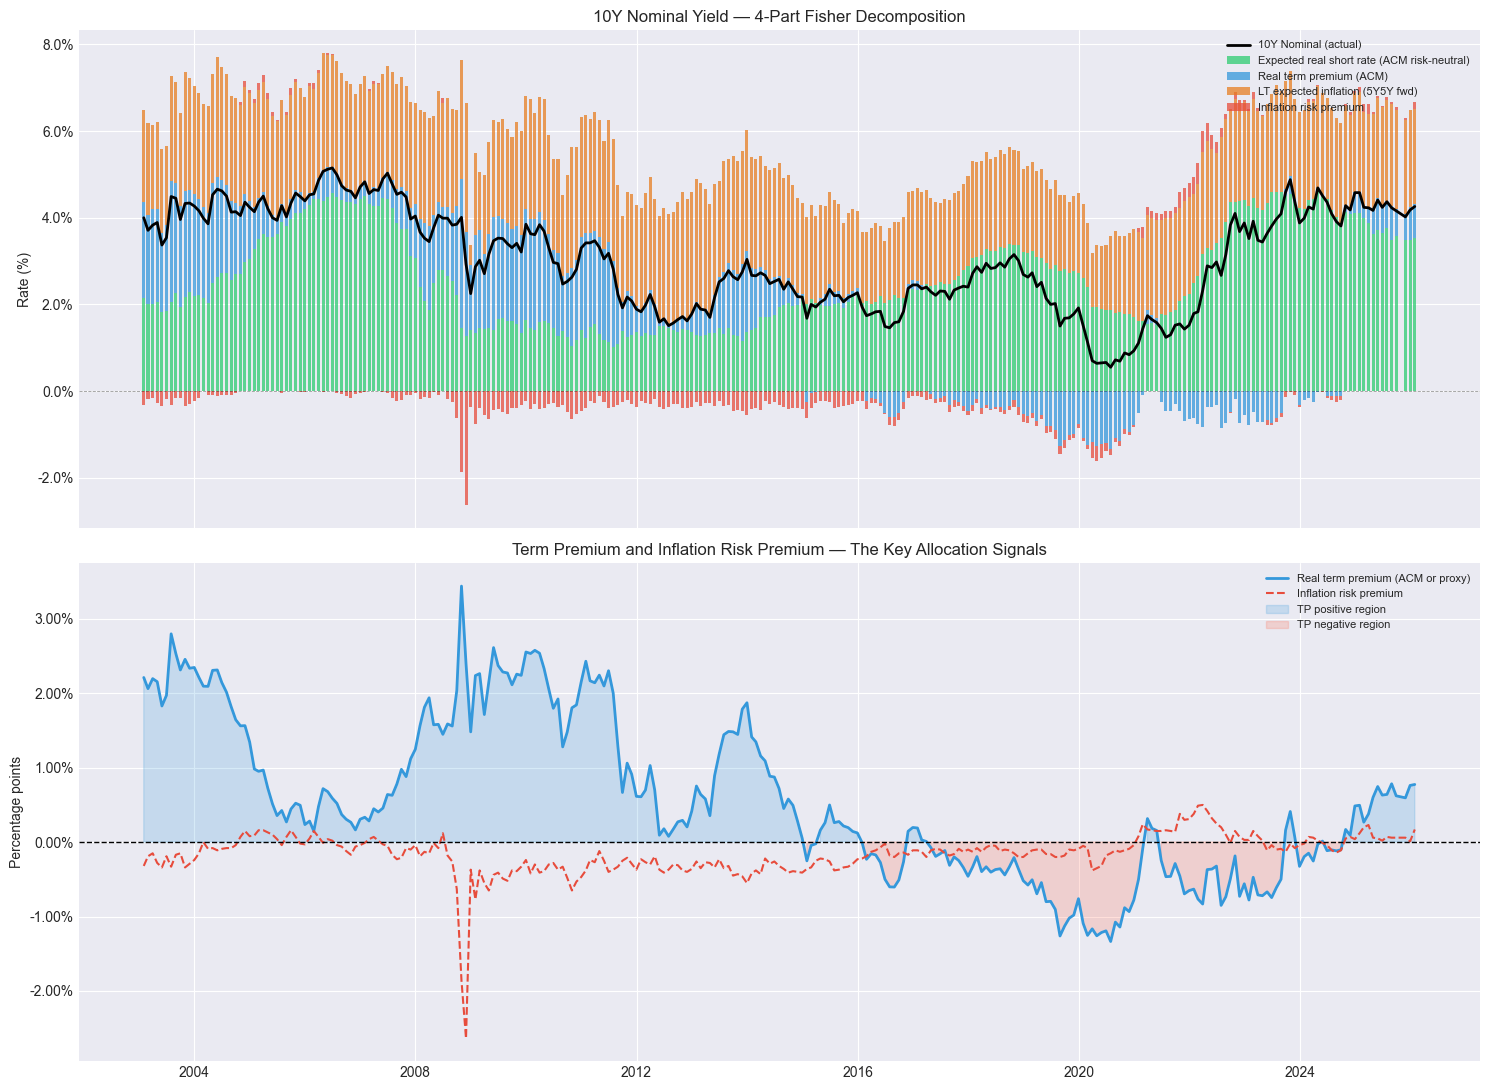

Saved -> output/fisher_decomposition.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

# ── Top: stacked area decomposition ────────────────────────────────────────
ax = axes[0]

# Stack the 4 components
components = [
    (rny,    '#2ecc71', 'Expected real short rate (ACM risk-neutral)'),
    (tp,     '#3498db', 'Real term premium (ACM)'),
    (fwd,    '#e67e22', 'LT expected inflation (5Y5Y fwd)'),
    (irp_c,  '#e74c3c', 'Inflation risk premium'),
]

# Handle negative values by splitting into positive/negative stacks
pos_vals = np.zeros(len(common))
neg_vals = np.zeros(len(common))

for s, color, label in components:
    vals = s.values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)
    ax.bar(common, pos, bottom=pos_vals, color=color, alpha=0.75,
           width=20, label=label)
    ax.bar(common, neg, bottom=neg_vals, color=color, alpha=0.75, width=20)
    pos_vals += pos
    neg_vals += neg

ax.plot(common, nom, 'k', linewidth=2, label='10Y Nominal (actual)')
ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.4)
ax.set_ylabel('Rate (%)')
ax.set_title('10Y Nominal Yield — 4-Part Fisher Decomposition')
ax.legend(fontsize=8, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# ── Bottom: term premium alone (the key allocation signal) ─────────────────
ax2 = axes[1]
ax2.plot(common, tp,   color='#3498db', linewidth=2, label='Real term premium (ACM or proxy)')
ax2.plot(common, irp_c, color='#e74c3c', linewidth=1.5,
         linestyle='--', label='Inflation risk premium')
ax2.fill_between(common, tp, 0,
                 where=(tp > 0), alpha=0.2, color='#3498db', label='TP positive region')
ax2.fill_between(common, tp, 0,
                 where=(tp < 0), alpha=0.2, color='tomato',  label='TP negative region')
ax2.axhline(0, color='k', linewidth=1, linestyle='--')
ax2.set_ylabel('Percentage points')
ax2.set_title('Term Premium and Inflation Risk Premium — The Key Allocation Signals')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'fisher_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/fisher_decomposition.png')


## Step 7: Historical Context — Four Eras

| Era | Nominal yield | Real yield | Breakeven | Term premium | What drove it |
|---|---|---|---|---|---|
| **Pre-GFC (2003–2007)** | ~5 % | ~2 % | ~2.5 % | ~1.5 % | Normal environment |
| **Post-GFC / QE (2009–2019)** | ~2–3 % | ~0–1 % | ~2 % | **−0.5 to 0 %** | QE compressed TP |
| **COVID / QE∞ (2020–2021)** | ~0.5–1.5 % | **−1 %** | ~1.5–2 % | **−1 %** | Fed pinned rates |
| **Hiking cycle (2022–now)** | ~4–5 % | ~1.5–2.5 % | ~2.5 % | **Rising** | QT + fiscal supply |

The key insight: during QE, yields were low primarily because the **term premium was compressed or negative**, not because real rates or inflation expectations were anchored. When QT began in 2022, the term premium repriced sharply — this is why long bonds sold off even after short rates peaked.


In [19]:
# Era averages
eras = {
    'Pre-GFC (2004-07)': (pd.Timestamp('2004-01-01'), pd.Timestamp('2007-07-01')),
    'Post-GFC QE (2010-19)': (pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-31')),
    'COVID QE (2020-21)': (pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31')),
    'Hiking (2022-now)': (pd.Timestamp('2022-01-01'), common.max()),
}

era_rows = []
for era_name, (start, end) in eras.items():
    mask = (common >= start) & (common <= end)
    if mask.sum() < 3: continue
    era_rows.append({
        'Era': era_name,
        'Nominal (%)':    round(nom[mask].mean(), 2),
        'Real yield (%)': round((dfii10_m.reindex(common)[mask]).mean(), 2),
        'Breakeven (%)':  round(be[mask].mean(), 2),
        'Term prem (%)':  round(tp[mask].mean(), 2),
        'Inf RP (%)':     round(irp_c[mask].mean(), 2),
        'Months':         int(mask.sum()),
    })

era_df = pd.DataFrame(era_rows).set_index('Era')
print('Era averages:\n')
print(era_df.to_string())


Era averages:

                       Nominal (%)  Real yield (%)  Breakeven (%)  Term prem (%)  Inf RP (%)  Months
Era                                                                                                 
Pre-GFC (2004-07)             4.49            2.03           2.46           0.89        0.01      42
Post-GFC QE (2010-19)         2.38            0.39           1.99           0.46       -0.26     120
COVID QE (2020-21)            1.14           -0.79           1.93          -0.69        0.02      24
Hiking (2022-now)             3.86            1.51           2.35          -0.10        0.07      48


## Step 8: Current Reading — What Is the 10Y Yield Telling Us Right Now?

The current decomposition answers the critical question: *is the long end cheap or rich?*

**Rule of thumb:**
- Term premium > 1.0 % → long end is **compensating you well** for duration risk → can extend
- Term premium 0–1 % → **neutral** → price it carefully
- Term premium < 0 % → long bonds are **expensive** relative to expected short rates → stay short


In [20]:
latest = common[-1]
print('=' * 60)
print(f'  Date: {latest.date()}')
print('=' * 60)

metrics = [
    ('10Y Nominal yield',           nom.iloc[-1]),
    ('10Y TIPS real yield',          dfii10_m.reindex(common).iloc[-1]),
    ('10Y Breakeven inflation',      be.iloc[-1]),
    ('LT expected inflation (5Y5Y)', fwd.iloc[-1]),
    ('Inflation risk premium',       irp_c.iloc[-1]),
    ('Term premium',                 tp.iloc[-1]),
    ('Risk-neutral rate',            rny.iloc[-1]),
]

for name, val in metrics:
    print(f'  {name:<38s}: {val:+.2f}%')

print()
tp_now = tp.iloc[-1]
if tp_now > 1.0:
    signal = 'HIGH — long end well compensated; consider extending duration'
elif tp_now > 0.0:
    signal = 'MODERATE — neutral; balance carry vs duration risk'
else:
    signal = 'LOW / NEGATIVE — long bonds rich; stay short duration'
print(f'  Term premium signal: {signal}')

irp_now = irp_c.iloc[-1]
if irp_now > 0.3:
    irp_signal = 'Elevated — market pricing inflation uncertainty; nominals cheap vs TIPS'
elif irp_now < -0.1:
    irp_signal = 'Negative — market confident in Fed anchoring; TIPS relatively expensive'
else:
    irp_signal = 'Normal — breakeven roughly equal to long-run expectations'
print(f'  Inflation RP signal: {irp_signal}')


  Date: 2026-01-31
  10Y Nominal yield                     : +4.26%
  10Y TIPS real yield                   : +1.90%
  10Y Breakeven inflation               : +2.36%
  LT expected inflation (5Y5Y)          : +2.19%
  Inflation risk premium                : +0.17%
  Term premium                          : +0.78%
  Risk-neutral rate                     : +3.54%

  Term premium signal: MODERATE — neutral; balance carry vs duration risk
  Inflation RP signal: Normal — breakeven roughly equal to long-run expectations


## Step 9: Term Premium vs Yield Curve Shape

The term premium and the **slope of the yield curve** are related but distinct:

- **Curve slope** = DGS10 − DGS2 → mostly driven by expectations about the rate cycle
- **Term premium** → driven by supply/demand for duration (QE buys duration, QT releases it; fiscal deficits increase Treasury supply)

During 2022–2023, the curve *inverted* (slope negative) even as the term premium was *rising* — because the market expected rates to fall eventually while simultaneously demanding more compensation for duration risk. These two forces can pull in opposite directions.


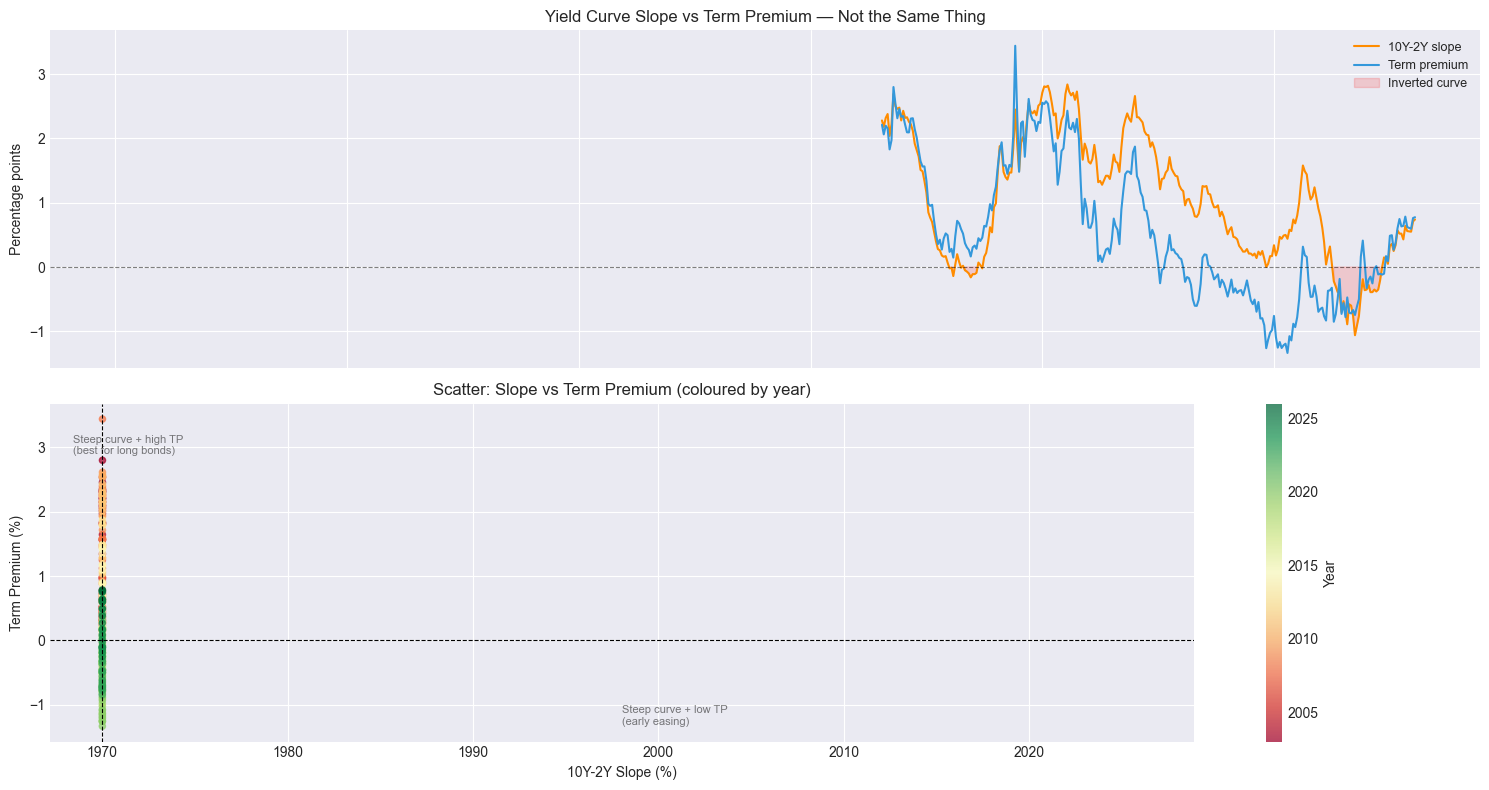

Saved -> output/fisher_tp_vs_slope.png


In [21]:
slope_m = (dgs10_m - dgs2_m).reindex(common)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax = axes[0]
ax.plot(common, slope_m, color='darkorange', linewidth=1.5, label='10Y-2Y slope')
ax.plot(common, tp,      color='#3498db',    linewidth=1.5, label='Term premium')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.fill_between(common, slope_m, 0, where=(slope_m < 0),
                alpha=0.15, color='red', label='Inverted curve')
ax.set_ylabel('Percentage points')
ax.set_title('Yield Curve Slope vs Term Premium — Not the Same Thing')
ax.legend(fontsize=9)

# Scatter: term premium vs slope
ax2 = axes[1]
scatter_data = pd.DataFrame({'slope': slope_m, 'tp': tp}).dropna()
years = scatter_data.index.year
sc = ax2.scatter(scatter_data['slope'], scatter_data['tp'],
                 c=years, cmap='RdYlGn', alpha=0.7, s=20)
plt.colorbar(sc, ax=ax2, label='Year')
ax2.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax2.axvline(0, color='k', linewidth=0.8, linestyle='--')
ax2.set_xlabel('10Y-2Y Slope (%)')
ax2.set_ylabel('Term Premium (%)')
ax2.set_title('Scatter: Slope vs Term Premium (coloured by year)')

# Add quadrant labels
ax2.text(0.5, 0.05, 'Steep curve + low TP\n(early easing)',
         transform=ax2.transAxes, fontsize=8, alpha=0.6)
ax2.text(0.02, 0.85, 'Steep curve + high TP\n(best for long bonds)',
         transform=ax2.transAxes, fontsize=8, alpha=0.6)

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'fisher_tp_vs_slope.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/fisher_tp_vs_slope.png')


## Step 10: Nominals vs TIPS — When to Own Which

The breakeven rate tells you the **break-even decision** directly:

- If you believe **realised inflation will exceed** the breakeven → buy TIPS
- If you believe **realised inflation will undershoot** the breakeven → buy nominals

The **inflation risk premium** complicates this: even if you think inflation will hit exactly the breakeven, nominals may still be preferable because the IRP means you are being paid extra to hold them.

The chart below shows the **rolling 1Y realised minus breakeven** — positive means TIPS won; negative means nominals won.


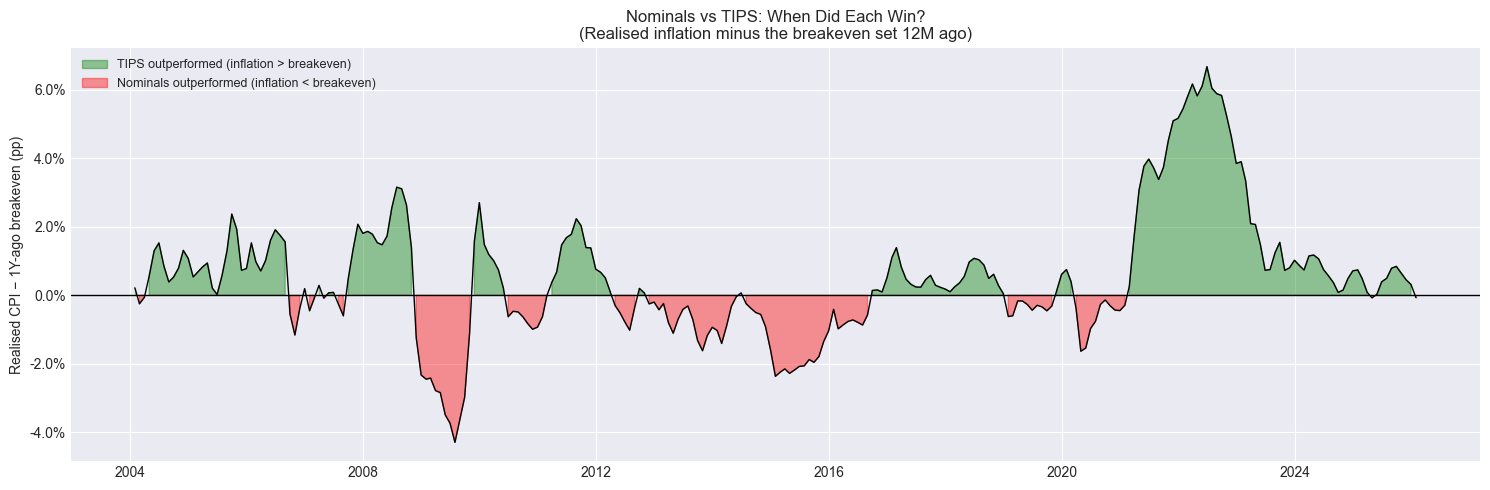

TIPS outperformed in 160/264 months (61% of the time)


In [22]:
# 1Y ahead realised CPI vs 1Y-ago breakeven
be10_lag12 = be10_m.shift(12).reindex(common)
tips_vs_nom = (cpi_yoy.reindex(common) - be10_lag12)

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(common, tips_vs_nom, 0,
                where=(tips_vs_nom > 0), alpha=0.4, color='green',
                label='TIPS outperformed (inflation > breakeven)')
ax.fill_between(common, tips_vs_nom, 0,
                where=(tips_vs_nom <= 0), alpha=0.4, color='red',
                label='Nominals outperformed (inflation < breakeven)')
ax.plot(common, tips_vs_nom, 'k', linewidth=1)
ax.axhline(0, color='k', linewidth=1)
ax.set_ylabel('Realised CPI − 1Y-ago breakeven (pp)')
ax.set_title('Nominals vs TIPS: When Did Each Win?\n'
             '(Realised inflation minus the breakeven set 12M ago)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout(); plt.show()

tips_win  = (tips_vs_nom > 0).sum()
total_obs = tips_vs_nom.dropna().shape[0]
print(f'TIPS outperformed in {tips_win}/{total_obs} months '
      f'({tips_win/total_obs*100:.0f}% of the time)')


## Step 11: Combine with HMM Regime — The Full Signal

The Fisher decomposition and the HMM regime detection are **complementary**:

| Signal | What it tells you | Source |
|---|---|---|
| HMM regime | *Which direction* rates are moving | `hmm_regime_detection.ipynb` |
| Term premium | *Whether* the long end fairly compensates you for the risk | This notebook |
| Breakeven / IRP | *Whether* inflation risk is priced in or not | This notebook |

### Decision matrix

| HMM regime | Term premium | Action |
|---|---|---|
| **Easing** | High (>1%) | *Maximum conviction*: extend duration aggressively |
| **Easing** | Low (<0.5%) | Extend modestly — not well paid for it |
| **Tightening** | High (>1%) | Avoid — TP high but price damage from rising rates outweighs |
| **Tightening** | Low (<0%) | Worst case — stay in cash / 3M bills |
| **Range-bound** | High (>0.5%) | Carry/rolldown play — 2Y–5Y, collect income |
| **Range-bound** | Low | Short duration, max carry from 3M–2Y |


In [23]:
# Print the current combined signal
print('=' * 65)
print('  CURRENT COMBINED SIGNAL')
print('=' * 65)
print(f'  Date:           {latest.date()}')
print(f'  10Y Nominal:    {nom.iloc[-1]:.2f}%')
print(f'  Term premium:   {tp.iloc[-1]:.2f}%')
print(f'  Inflation RP:   {irp_c.iloc[-1]:.2f}%')
print(f'  Real yield:     {dfii10_m.reindex(common).iloc[-1]:.2f}%')
print(f'  5Y5Y fwd infl:  {fwd.iloc[-1]:.2f}%')
print()

if not HAS_ACM:
    print('  Note: term premium is an approximation (ACM data unavailable).')
    print('  For precise values visit: https://www.newyorkfed.org/research/data_indicators/term-premia-tabs')
print()

# Duration guidance
tp_val = tp.iloc[-1]
print('  Implied duration guidance from Fisher decomposition:')
if tp_val > 1.0:
    print('  -> Term premium is HIGH. Long-end bonds are CHEAP on risk-adjusted basis.')
    print('     Pair with HMM regime: if Easing/Range-bound, extend duration to 10Y+.')
elif tp_val > 0.3:
    print('  -> Term premium is MODERATE. Long-end offers fair compensation.')
    print('     Focus on 5Y-10Y for balanced carry + duration.')
else:
    print('  -> Term premium is LOW. Long-end bonds are EXPENSIVE vs short rates.')
    print('     Stay in 2Y-5Y range. Do not pay for duration that is not compensated.')

irp_val = irp_c.iloc[-1]
print()
print('  Nominals vs TIPS:')
if irp_val > 0.4:
    print(f'  -> IRP = {irp_val:.2f}%. Nominals priced with elevated inflation uncertainty.')
    print('     If you expect inflation to fall toward 2%, nominals offer extra IRP pickup.')
elif irp_val < 0:
    print(f'  -> IRP = {irp_val:.2f}%. Market very confident about inflation.')
    print('     TIPS offer no extra yield over nominals. Prefer nominals.')
else:
    print(f'  -> IRP = {irp_val:.2f}%. Normal range. Choice driven by inflation view.')


  CURRENT COMBINED SIGNAL
  Date:           2026-01-31
  10Y Nominal:    4.26%
  Term premium:   0.78%
  Inflation RP:   0.17%
  Real yield:     1.90%
  5Y5Y fwd infl:  2.19%


  Implied duration guidance from Fisher decomposition:
  -> Term premium is MODERATE. Long-end offers fair compensation.
     Focus on 5Y-10Y for balanced carry + duration.

  Nominals vs TIPS:
  -> IRP = 0.17%. Normal range. Choice driven by inflation view.


## Summary

| What we built | Why it matters |
|---|---|
| Basic decomposition: Nominal = TIPS + Breakeven | Observable from market prices, no model needed |
| Breakeven split: LT expected + IRP | IRP tells you inflation uncertainty pricing |
| ACM term premium (or proxy) | The single most important signal for duration positioning |
| 4-part stacked area chart | Full picture of what drives the 10Y yield |
| Historical era comparison | Context for current levels |
| TP vs curve slope scatter | Shows they are different despite both being 'yield signals' |
| TIPS vs nominal decision | Quantifies when each asset class wins |
| Combined signal table | Maps TP + HMM regime to a concrete duration call |

### Next steps
1. **Nelson-Siegel-Svensson** (`nelson_siegel_svensson.ipynb`) — fit a parametric curve to extract forward rates at any maturity, sharpening the rolldown calculation in your efficient frontier.
2. **Black-Litterman** (`black_litterman.ipynb`) — formalise your HMM regime + Fisher TP views into a BL prior and blend with the market-implied efficient frontier.
